<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




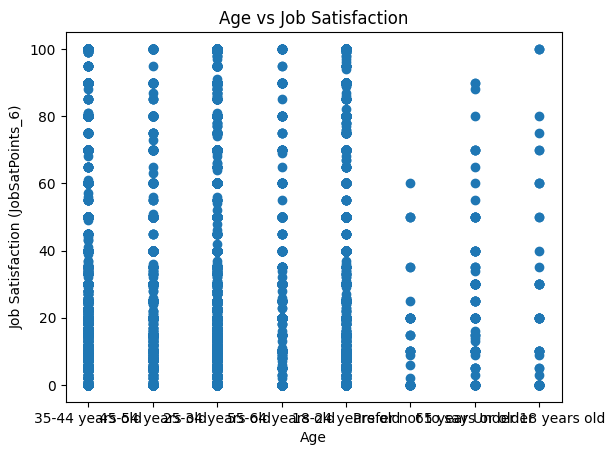

In [3]:
# Select relevant columns and drop missing values
df_clean_1 = df[['Age', 'JobSatPoints_6']].dropna()

# Create scatter plot
plt.figure()
plt.scatter(df_clean_1['Age'], df_clean_1['JobSatPoints_6'], alpha=0.4, color='steelblue')

# Labels and title
plt.xlabel('Age')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Age vs Job Satisfaction')

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


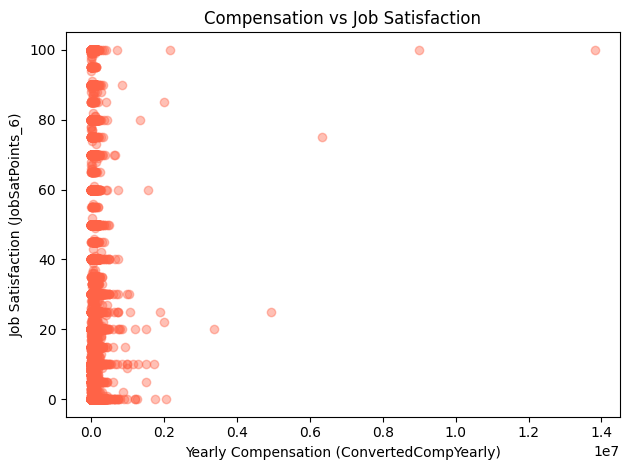

In [5]:
# Select relevant columns and drop missing values
df_clean_2 = df[['ConvertedCompYearly', 'JobSatPoints_6']].dropna()

# Create scatter plot
plt.figure()
plt.scatter(df_clean_2['ConvertedCompYearly'], df_clean_2['JobSatPoints_6'], alpha=0.4, color='tomato')

# Labels and title
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')
plt.title('Compensation vs Job Satisfaction')

plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [11]:
# Clean data safely
df_clean_1 = df[['Age', 'JobSatPoints_6']].copy()
df_clean_1['Age'] = pd.to_numeric(df_clean_1['Age'], errors='coerce')
df_clean_1['JobSatPoints_6'] = pd.to_numeric(df_clean_1['JobSatPoints_6'], errors='coerce')
df_clean_1 = df_clean_1.dropna()

if len(df_clean_1) > 0:
    x = df_clean_1['Age']
    y = df_clean_1['JobSatPoints_6']

    plt.figure()
    plt.scatter(x, y, alpha=0.4, color='steelblue')

    # Trend line
    m, b = np.polyfit(x, y, 1)
    plt.plot(sorted(x), [m * xi + b for xi in sorted(x)], color='red', linewidth=2, label='Trend line')

    plt.xlabel('Age')
    plt.ylabel('Job Satisfaction (JobSatPoints_6)')
    plt.title('Age vs Job Satisfaction with Trend Line')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No valid numeric data available for plotting.')

No valid numeric data available for plotting.

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [12]:
# Clean data safely
df_clean_2 = df[['Age', 'YearsCodePro']].copy()

# Handle special string values in YearsCodePro
df_clean_2['YearsCodePro'] = df_clean_2['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

df_clean_2['Age'] = pd.to_numeric(df_clean_2['Age'], errors='coerce')
df_clean_2['YearsCodePro'] = pd.to_numeric(df_clean_2['YearsCodePro'], errors='coerce')
df_clean_2 = df_clean_2.dropna()

if len(df_clean_2) > 0:
    plt.figure()
    plt.scatter(df_clean_2['Age'], df_clean_2['YearsCodePro'], alpha=0.4, color='seagreen')
    plt.xlabel('Age')
    plt.ylabel('Years of Professional Coding Experience')
    plt.title('Age vs Work Experience')
    plt.tight_layout()
    plt.show()
else:
    print('No valid numeric data available for plotting.')

No valid numeric data available for plotting.

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


In [13]:
# Clean data safely
df_clean_3 = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].copy()
df_clean_3['ConvertedCompYearly'] = pd.to_numeric(df_clean_3['ConvertedCompYearly'], errors='coerce')
df_clean_3['JobSatPoints_6'] = pd.to_numeric(df_clean_3['JobSatPoints_6'], errors='coerce')
df_clean_3['Age'] = pd.to_numeric(df_clean_3['Age'], errors='coerce')
df_clean_3 = df_clean_3.dropna()

# Filter outliers in compensation for better visibility
df_clean_3 = df_clean_3[df_clean_3['ConvertedCompYearly'] < 300000]

if len(df_clean_3) > 0:
    plt.figure(figsize=(10, 6))

    bubble_size = df_clean_3['Age'] * 2  # scale bubble size by age

    plt.scatter(
        df_clean_3['ConvertedCompYearly'],
        df_clean_3['JobSatPoints_6'],
        s=bubble_size,
        alpha=0.5,
        color='steelblue',
        edgecolors='white',
        linewidth=0.5
    )

    plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
    plt.ylabel('Job Satisfaction (JobSatPoints_6)')
    plt.title('Compensation vs Job Satisfaction\n(Bubble Size = Age)')
    plt.tight_layout()
    plt.show()
else:
    print('No valid numeric data available for plotting.')

No valid numeric data available for plotting.

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


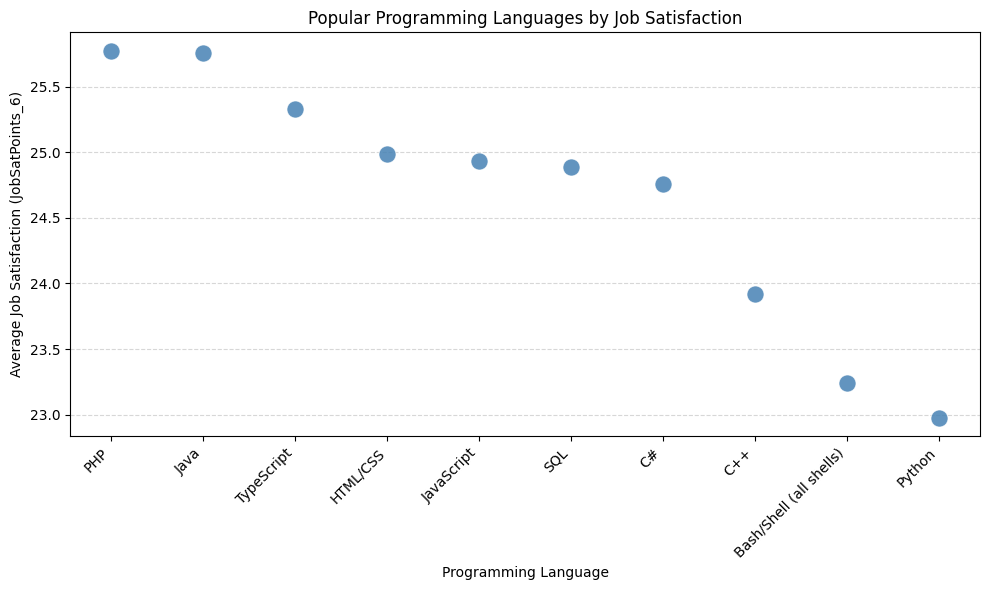

In [14]:
# Clean data safely
df_clean_4 = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']].copy()
df_clean_4['JobSatPoints_6'] = pd.to_numeric(df_clean_4['JobSatPoints_6'], errors='coerce')
df_clean_4 = df_clean_4.dropna()

# Split multiple languages per row (separated by ';')
df_lang = df_clean_4.assign(
    LanguageHaveWorkedWith=df_clean_4['LanguageHaveWorkedWith'].str.split(';')
).explode('LanguageHaveWorkedWith')
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.strip()

# Get top 10 most popular languages
top_langs = df_lang['LanguageHaveWorkedWith'].value_counts().head(10).index
df_lang_top = df_lang[df_lang['LanguageHaveWorkedWith'].isin(top_langs)]

# Calculate average job satisfaction per language
lang_sat = df_lang_top.groupby('LanguageHaveWorkedWith')['JobSatPoints_6'].mean().reset_index()
lang_sat.columns = ['Language', 'AvgJobSatisfaction']
lang_sat = lang_sat.sort_values('AvgJobSatisfaction', ascending=False)

if len(lang_sat) > 0:
    plt.figure(figsize=(10, 6))

    plt.scatter(
        lang_sat['Language'],
        lang_sat['AvgJobSatisfaction'],
        s=150,
        color='steelblue',
        edgecolors='white',
        linewidth=0.5,
        alpha=0.85,
        zorder=3
    )

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xlabel('Programming Language')
    plt.ylabel('Average Job Satisfaction (JobSatPoints_6)')
    plt.title('Popular Programming Languages by Job Satisfaction')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No valid data available for plotting.')

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


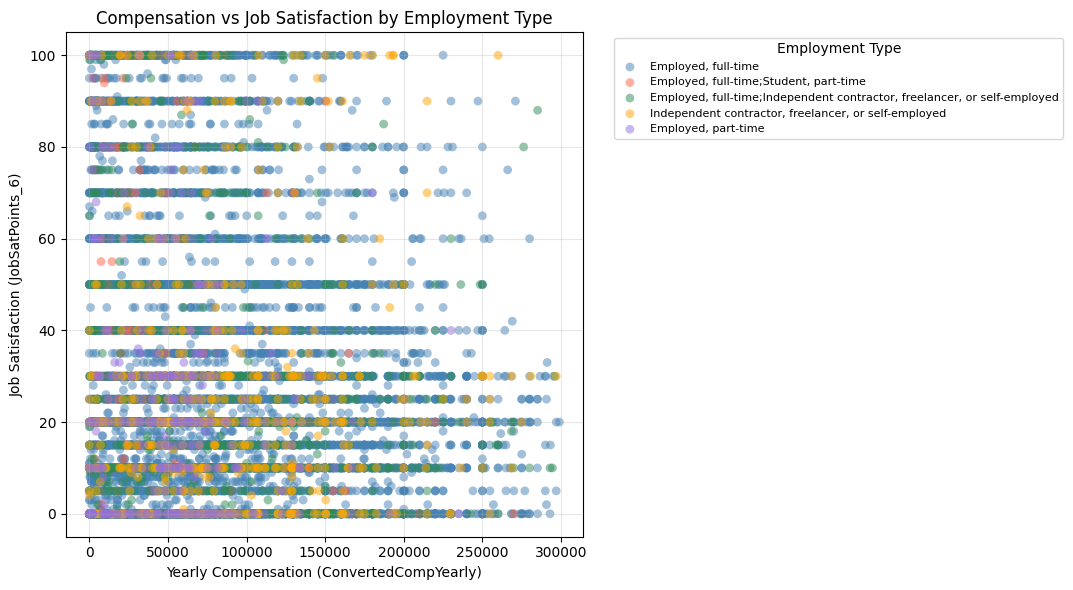

In [16]:
# Clean data safely
df_clean_5 = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']].copy()
df_clean_5['ConvertedCompYearly'] = pd.to_numeric(df_clean_5['ConvertedCompYearly'], errors='coerce')
df_clean_5['JobSatPoints_6'] = pd.to_numeric(df_clean_5['JobSatPoints_6'], errors='coerce')
df_clean_5 = df_clean_5.dropna()

# Filter outliers for better visibility
df_clean_5 = df_clean_5[df_clean_5['ConvertedCompYearly'] < 300000]

# Get top 5 employment types to avoid clutter from rare categories
top_employment = df_clean_5['Employment'].value_counts().head(5).index
df_clean_5 = df_clean_5[df_clean_5['Employment'].isin(top_employment)]

if len(df_clean_5) > 0:
    plt.figure(figsize=(11, 6))

    colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']
    employment_types = df_clean_5['Employment'].unique()

    for i, emp_type in enumerate(employment_types):
        subset = df_clean_5[df_clean_5['Employment'] == emp_type]
        plt.scatter(
            subset['ConvertedCompYearly'],
            subset['JobSatPoints_6'],
            label=emp_type,
            color=colors[i % len(colors)],
            alpha=0.5,
            s=40,
            edgecolors='none'
        )

    plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
    plt.ylabel('Job Satisfaction (JobSatPoints_6)')
    plt.title('Compensation vs Job Satisfaction by Employment Type')
    plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No valid numeric data available for plotting.')

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [15]:
# Clean data safely
df_clean_6 = df[['YearsCodePro', 'Age', 'Country']].copy()

# Handle special string values in YearsCodePro
df_clean_6['YearsCodePro'] = df_clean_6['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

df_clean_6['YearsCodePro'] = pd.to_numeric(df_clean_6['YearsCodePro'], errors='coerce')
df_clean_6['Age'] = pd.to_numeric(df_clean_6['Age'], errors='coerce')
df_clean_6 = df_clean_6.dropna()

# Create Age Groups
bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55+']
df_clean_6['AgeGroup'] = pd.cut(df_clean_6['Age'], bins=bins, labels=labels, right=False)

# Top 5 countries to avoid clutter
top_countries = df_clean_6['Country'].value_counts().head(5).index
df_clean_6 = df_clean_6[df_clean_6['Country'].isin(top_countries)]

# Marker styles per age group
markers = ['o', 's', '^', 'D', 'P', '*']
age_groups = labels

# Colors per country
colors = ['steelblue', 'tomato', 'seagreen', 'orange', 'mediumpurple']
countries = list(top_countries)

if len(df_clean_6) > 0:
    plt.figure(figsize=(12, 7))

    for i, country in enumerate(countries):
        for j, age_group in enumerate(age_groups):
            subset = df_clean_6[
                (df_clean_6['Country'] == country) &
                (df_clean_6['AgeGroup'] == age_group)
            ]
            if len(subset) > 0:
                plt.scatter(
                    subset['Age'],
                    subset['YearsCodePro'],
                    color=colors[i % len(colors)],
                    marker=markers[j % len(markers)],
                    alpha=0.5,
                    s=50,
                    label=f"{country} | {age_group}" if j == 0 else ""
                )

    plt.xlabel('Age')
    plt.ylabel('Years of Professional Coding Experience')
    plt.title('Work Experience vs Age Group by Country')
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No valid numeric data available for plotting.')

No valid numeric data available for plotting.

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
